# Download the Splited Dataset

In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/cfp-splited-and-completed")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: lama2134
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/lama2134/cfp-splited-and-completed


100%|██████████| 2.16G/2.16G [00:13<00:00, 170MB/s]


# 'Erosion' Preprocessed dataset

In [ ]:
import cv2
import numpy as np
import os


input_folder = "/content/cfp-splited-and-completed"
output_folder = "/content/Processed_Images"
os.makedirs(output_folder, exist_ok=True)


kernel = np.ones((5, 5), np.uint8)


splits = ["train", "val", "test"]  #

# Process each split (train, val, test)
for split in splits:
    split_path = os.path.join(input_folder, split)
    output_split_path = os.path.join(output_folder, split)
    os.makedirs(output_split_path, exist_ok=True)

    # Process each class (Normal, cataract, diabetic_retinopathy, glaucoma)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        output_class_path = os.path.join(output_split_path, class_name)
        os.makedirs(output_class_path, exist_ok=True)

        if os.path.isdir(class_path):
            for filename in os.listdir(class_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(class_path, filename)
                    image = cv2.imread(image_path)

                    if image is not None:

                        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                        green_channel = image_rgb[:, :, 1]


                        eroded_green = cv2.erode(green_channel, kernel, iterations=1)


                        output_image_path = os.path.join(output_class_path, f"processed_{filename}")
                        cv2.imwrite(output_image_path, eroded_green)
                        print(f"Processed and saved: {output_image_path}")
                    else:
                        print(f"Failed to load: {image_path}")

print("Processing completed for train, val, and test datasets.")


Streaming output truncated to the last 5000 lines.
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (2439).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (2077).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (315).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (940).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (928).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (1687).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (2551).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (2553).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (1350).jpg
Processed and saved: /content/Processed_Images/val/cataract/processed_cataract (2774).jpg
Processed and saved: /content/Processed_Images/val/c

In [ ]:
def count_images(directory):
    if not os.path.exists(directory):
        return f"Error: '{directory}' does not exist."

    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

print("Training set:", count_images("/content/Processed_Images/train"))
print("Validation set:", count_images("/content/Processed_Images/val"))
print("Testing set:", count_images("/content/Processed_Images/test"))

Training set: {'glaucoma': 1691, 'cataract': 1743, 'diabetic_retinopathy': 1844, 'Normal': 1804}
Validation set: {'glaucoma': 423, 'cataract': 436, 'diabetic_retinopathy': 461, 'Normal': 451}
Testing set: {'glaucoma': 907, 'cataract': 935, 'diabetic_retinopathy': 989, 'Normal': 967}


In [ ]:
import shutil
output_path="/content/Processed_Images"
zip_file = "/content/Processed_Images.zip"
shutil.make_archive(zip_file.replace(".zip", ""), 'zip', output_path)

'/content/Processed_Images.zip'

In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/processeder-images")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

# 'unsharp_mask' Preprocessed dataset

In [ ]:
import cv2
import numpy as np
import os

def denoise_image(image, strength=3):
    return cv2.fastNlMeansDenoising(image, None, strength, 7, 21)

def improved_guided_filter(image, radius=35, eps=1e-6):
    blurred = cv2.GaussianBlur(image, (radius, radius), 0)
    dehazed = cv2.addWeighted(image, 2.2, blurred, -1.2, eps)
    return np.clip(dehazed, 0, 255).astype(np.uint8)

# Initialize CLAHE
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))

def unsharp_mask(image, sigma=1.2, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

cv2.setUseOptimized(True)


input_folder = "/content/cfp-splited-and-completed"
output_folder = "/content/ProcessedGH_Images"
os.makedirs(output_folder, exist_ok=True)


splits = ["train", "val", "test"]

# Process each split (train, val, test)
for split in splits:
    split_path = os.path.join(input_folder, split)
    output_split_path = os.path.join(output_folder, split)
    os.makedirs(output_split_path, exist_ok=True)

    # Process each class (Normal, cataract, diabetic_retinopathy, glaucoma)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        output_class_path = os.path.join(output_split_path, class_name)
        os.makedirs(output_class_path, exist_ok=True)

        if os.path.isdir(class_path):
            for filename in os.listdir(class_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(class_path, filename)
                    image = cv2.imread(image_path)

                    if image is not None:

                        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

                        # Apply processing steps
                        denoised = denoise_image(gray)
                        dehazed = improved_guided_filter(denoised)
                        clahe_img = clahe.apply(dehazed)
                        sharp_enhanced = unsharp_mask(clahe_img)


                        output_image_path = os.path.join(output_class_path, f"processed_{filename}")
                        cv2.imwrite(output_image_path, sharp_enhanced)
                        print(f"Processed and saved: {output_image_path}")
                    else:
                        print(f"Failed to load: {image_path}")

print("Processing completed for train, val, and test datasets.")


Streaming output truncated to the last 5000 lines.
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (690).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (1833).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (1596).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (2206).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (2817).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (1538).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (768).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (576).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (1350).jpg
Processed and saved: /content/ProcessedGH_Images/val/glaucoma/processed_glaucoma (231).jpg
Processed and saved: /content/Pro

In [ ]:
def count_images(directory):
    if not os.path.exists(directory):
        return f"Error: '{directory}' does not exist."

    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

print("Training set:", count_images("/content/ProcessedGH_Images/train"))
print("Validation set:", count_images("/content/ProcessedGH_Images/val"))
print("Testing set:", count_images("/content/ProcessedGH_Images/test"))

Training set: {'Normal': 1804, 'glaucoma': 1691, 'cataract': 1743, 'diabetic_retinopathy': 1844}
Validation set: {'Normal': 451, 'glaucoma': 423, 'cataract': 436, 'diabetic_retinopathy': 461}
Testing set: {'Normal': 967, 'glaucoma': 907, 'cataract': 935, 'diabetic_retinopathy': 989}


In [ ]:
import shutil
output_path="/content/ProcessedGH_Images"
zip_file = "/content/ProcessedGH_Images.zip"
shutil.make_archive(zip_file.replace(".zip", ""), 'zip', output_path)

'/content/ProcessedGH_Images.zip'

In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/processeder-images")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

# VGG Model trining on the Erosion dataset

In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/processeder-images")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: lama2134
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/lama2134/processeder-images


In [ ]:
from tensorflow.keras.models import load_model
loaded_model = load_model('/content/CFP_vgg19_model.keras')
loaded_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 384)            │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,540 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,038,094 (232.84 MB)

 Trainable params: 20,345,988 (77.61 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 40,691,978 (155.23 MB)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model


dataset_dir = '/content/processeder-images'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')


train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse"
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)


Found 7082 images belonging to 4 classes.
Found 1771 images belonging to 4 classes.
Found 3798 images belonging to 4 classes.


In [ ]:

epochs = 10
history = loaded_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 149s 601ms/step - accuracy: 0.8618 - loss: 0.7778 - val_accuracy: 0.8865 - val_loss: 0.7330
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 584ms/step - accuracy: 0.9180 - loss: 0.6101 - val_accuracy: 0.9164 - val_loss: 0.6128
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 584ms/step - accuracy: 0.9464 - loss: 0.5377 - val_accuracy: 0.8820 - val_loss: 0.6728
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 583ms/step - accuracy: 0.9649 - loss: 0.4922 - val_accuracy: 0.9571 - val_loss: 0.4985
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 584ms/step - accuracy: 0.9793 - loss: 0.4367 - val_accuracy: 0.9385 - val_loss: 0.5318
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 142s 585ms/step - accuracy: 0.9849 - loss: 0.4136 - val_accuracy: 0.9503 - val_loss: 0.4899
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 583ms/step - accuracy: 0.9904 - loss: 0.3825 - val_accuracy: 0.9554 - val_loss: 0.4657
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 584ms/step - accuracy: 0.9958 -

In [ ]:

test_loss, test_accuracy = loaded_model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.9790 - loss: 0.3711
Test Loss: 0.3618
Test Accuracy: 0.9808


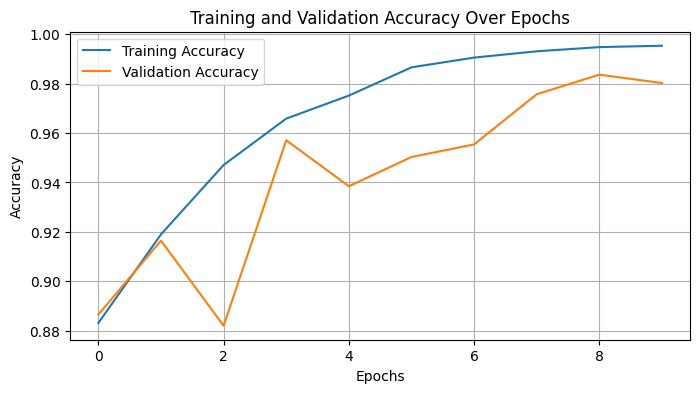

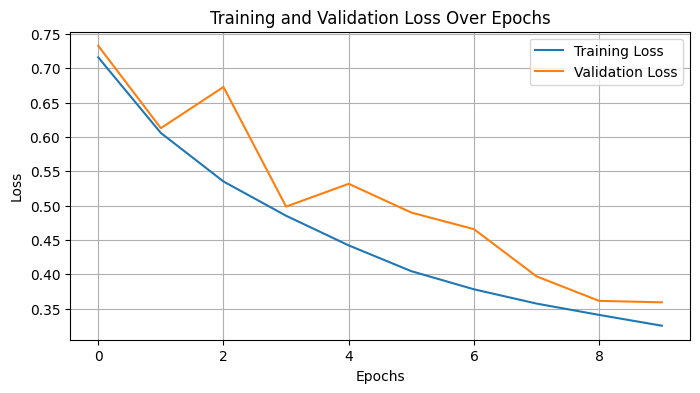

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step


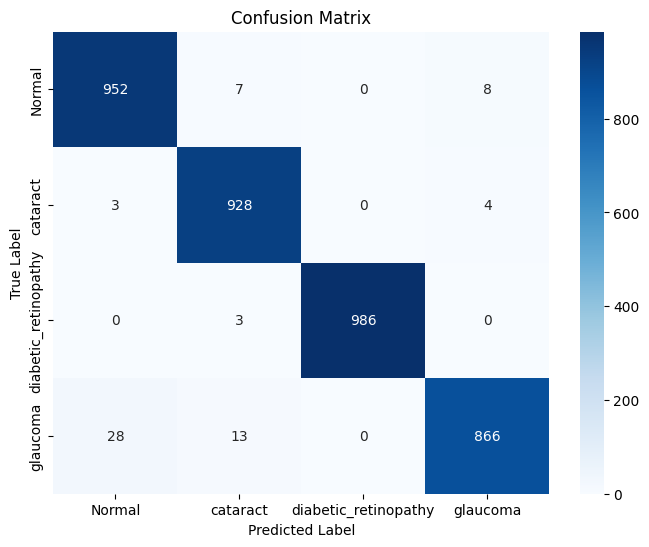

In [ ]:

y_true = test_generator.classes
y_pred = loaded_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:

print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

Classification Report:
                       precision    recall  f1-score   support

              Normal       0.97      0.98      0.98       967
            cataract       0.98      0.99      0.98       935
diabetic_retinopathy       1.00      1.00      1.00       989
            glaucoma       0.99      0.95      0.97       907

            accuracy                           0.98      3798
           macro avg       0.98      0.98      0.98      3798
        weighted avg       0.98      0.98      0.98      3798



# VGG Model trining on the Unsharp dataset

In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/processedgh-images")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: lama2134
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/lama2134/processedgh-images


In [ ]:
from tensorflow.keras.models import load_model
loaded_model = load_model('/content/CFP_vgg19_model.keras')
loaded_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 384)            │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,540 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,038,094 (232.84 MB)

 Trainable params: 20,345,988 (77.61 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 40,691,978 (155.23 MB)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model


dataset_dir = '/content/processedgh-images'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')


train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse"
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)


Found 7082 images belonging to 4 classes.
Found 1771 images belonging to 4 classes.
Found 3798 images belonging to 4 classes.


In [ ]:
epochs = 10
history = loaded_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 136s 595ms/step - accuracy: 0.8479 - loss: 0.7997 - val_accuracy: 0.8442 - val_loss: 0.7976
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 142s 638ms/step - accuracy: 0.9383 - loss: 0.5826 - val_accuracy: 0.9289 - val_loss: 0.5816
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 131s 589ms/step - accuracy: 0.9682 - loss: 0.4909 - val_accuracy: 0.9718 - val_loss: 0.4666
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 131s 591ms/step - accuracy: 0.9898 - loss: 0.4262 - val_accuracy: 0.9616 - val_loss: 0.4736
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 588ms/step - accuracy: 0.9965 - loss: 0.3893 - val_accuracy: 0.9718 - val_loss: 0.4545
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 142s 590ms/step - accuracy: 0.9946 - loss: 0.3760 - val_accuracy: 0.9887 - val_loss: 0.3799
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 130s 587ms/step - accuracy: 0.9998 - loss: 0.3457 - val_accuracy: 0.9864 - val_loss: 0.3706
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 131s 589ms/step - accuracy: 0.9996 -

In [ ]:

test_loss, test_accuracy = loaded_model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.9598 - loss: 0.4069
Test Loss: 0.4033
Test Accuracy: 0.9608


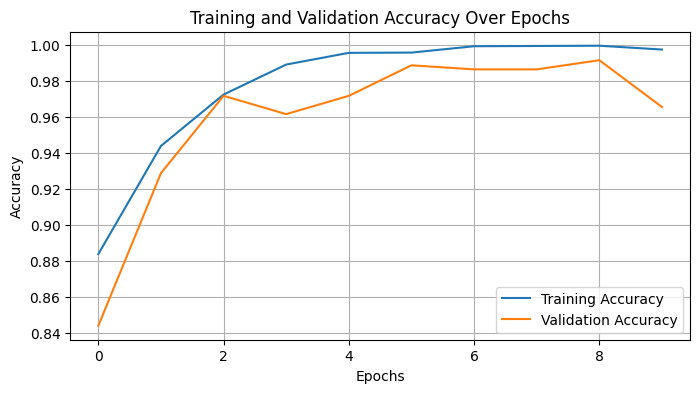

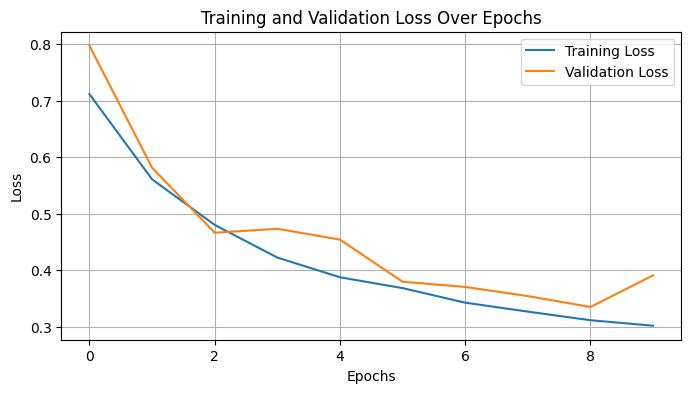

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step


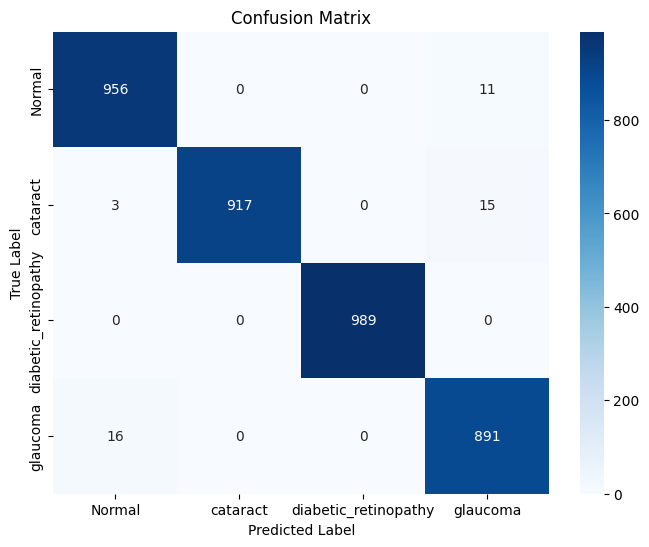

In [ ]:

y_true = test_generator.classes
y_pred = loaded_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:

print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

Classification Report:
                       precision    recall  f1-score   support

              Normal       0.98      0.99      0.98       967
            cataract       1.00      0.98      0.99       935
diabetic_retinopathy       1.00      1.00      1.00       989
            glaucoma       0.97      0.98      0.98       907

            accuracy                           0.99      3798
           macro avg       0.99      0.99      0.99      3798
        weighted avg       0.99      0.99      0.99      3798



# Efficientnet Model trining on the Erosion dataset


In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/processeder-images")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

Skipping, found downloaded files in "./processeder-images" (use force=True to force download)


In [ ]:
!pip install pytorch-lightning


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 57.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitli

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from collections import OrderedDict


class EfficientNetB3Lightning(pl.LightningModule):
    def __init__(self, num_classes=4):
        super(EfficientNetB3Lightning, self).__init__()
        self.model = timm.create_model('efficientnet_b3.ra2_in1k', pretrained=False)
        num_ftrs = self.model.classifier.in_features


        self.model.classifier = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()

        # Log metrics with progress bar
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()

        # Log metrics with progress bar
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=0.0001)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
        return [optimizer], [scheduler]



In [ ]:
data_dir = '/content/processeder-images'
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(288),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(288),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

train_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(f'{data_dir}/val', transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

In [ ]:
model = EfficientNetB3Lightning(num_classes=4)

trainer = pl.Trainer(
    max_epochs=25,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu'
)


trainer.fit(model, train_loader, val_loader)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | EfficientNet     | 11.6 M | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


In [ ]:

model = model.to(device)


model.eval()

test_size = len(dataloaders['test'].dataset)

with torch.no_grad():
    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    # Loop through the test data
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)


        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)


        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    test_loss = test_loss / test_size
    test_accuracy = correct / total


    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")



Test Loss: 0.1491
Test Accuracy: 0.9645


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from collections import OrderedDict


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class EfficientNetB3Lightning(pl.LightningModule):
    def __init__(self, num_classes=4):
        super(EfficientNetB3Lightning, self).__init__()
        self.model = timm.create_model('efficientnet_b3.ra2_in1k', pretrained=False)
        num_ftrs = self.model.classifier.in_features


        self.model.classifier = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()


        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()


        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=0.0001)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
        return [optimizer], [scheduler]

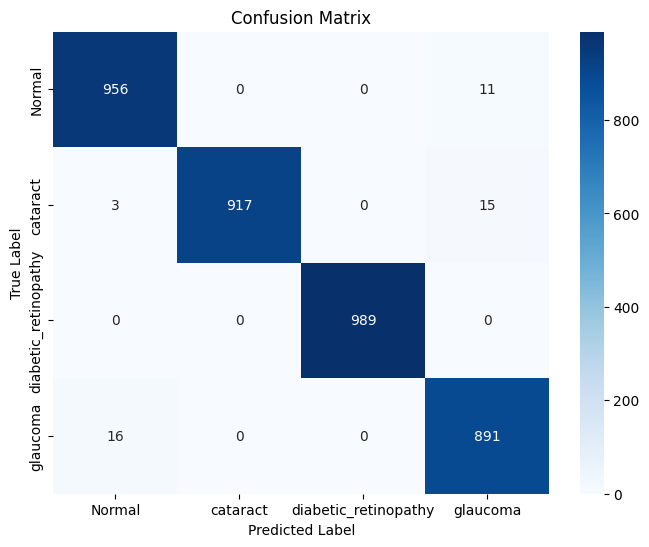

In [ ]:
class_names = dataloaders['test'].dataset.classes


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


data_dir = '/content/processeder-images'


mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


test_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


test_dataset = datasets.ImageFolder(f'{data_dir}/test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


dataloaders = {
    'test': test_loader
}

In [ ]:
from sklearn.metrics import classification_report
import numpy as np




y_pred = loaded_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)


print("Classification Report:\n",
      classification_report(y_true, y_pred_classes, target_names=class_names))

119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step
Classification Report:
                       precision    recall  f1-score   support

              Normal       0.98      0.99      0.98       967
            cataract       1.00      0.98      0.99       935
diabetic_retinopathy       1.00      1.00      1.00       989
            glaucoma       0.97      0.98      0.98       907

            accuracy                           0.99      3798
           macro avg       0.99      0.99      0.99      3798
        weighted avg       0.99      0.99      0.99      3798



# Efficientnet Model trining on the Unsharp dataset

In [ ]:
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
from IPython.display import clear_output
!cp kaggle.json ~./kaggle
!pip install opendatasets
clear_output()
import opendatasets as od

od.download("https://www.kaggle.com/datasets/lama2134/processedgh-images")
# 0ba003432dd7ab5c0695b0db0aef7cf1
# lama2134

Skipping, found downloaded files in "./processedgh-images" (use force=True to force download)


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from collections import OrderedDict


class EfficientNetB3Lightning(pl.LightningModule):
    def __init__(self, num_classes=4):
        super(EfficientNetB3Lightning, self).__init__()
        self.model = timm.create_model('efficientnet_b3.ra2_in1k', pretrained=False)


        num_ftrs = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )


        self.criterion = nn.CrossEntropyLoss()


        model_load_path = '/content/efficientnet_b3_best_2.pth'
        state_dict = torch.load(model_load_path)
        self.model.load_state_dict(state_dict, strict=True)


        for param in self.model.parameters():
            param.requires_grad = False


        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()


        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()


        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=0.0001)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
        return [optimizer], [scheduler]



In [ ]:
data_dir = '/content/processedgh-images'
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(288),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(288),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
}

train_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(f'{data_dir}/val', transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)


In [ ]:
model = EfficientNetB3Lightning(num_classes=4)

trainer = pl.Trainer(
    max_epochs=25,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu'
)


trainer.fit(model, train_loader, val_loader)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | EfficientNet     | 11.6 M | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
11.6 M    Trainable params
0         Non-trainable params
11.6 M    Total params
46.474    Total estimated model params size (MB)
542       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Assuming you already have a directory for test data
data_dir = '/content/processedgh-images'

# Use the same normalization as the model
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Define the transformations for the test set
test_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load the test dataset
test_dataset = datasets.ImageFolder(f'{data_dir}/test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# Store the DataLoader in a dictionary for compatibility
dataloaders = {
    'test': test_loader
}


In [ ]:
# Define the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure the model is on the correct device
model = model.to(device)

# Set the model to evaluation mode
model.eval()

# Get the size of the test set
test_size = len(dataloaders['test'].dataset)

# Disable gradient calculation for faster evaluation
with torch.no_grad():
    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    # Loop through the test data
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)   # Move inputs to the device
        labels = labels.to(device)   # Move labels to the device

        # Forward Pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate average loss and accuracy
test_loss = test_loss / test_size
test_accuracy = correct / total

# Display the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



Test Loss: 0.1697
Test Accuracy: 0.9589


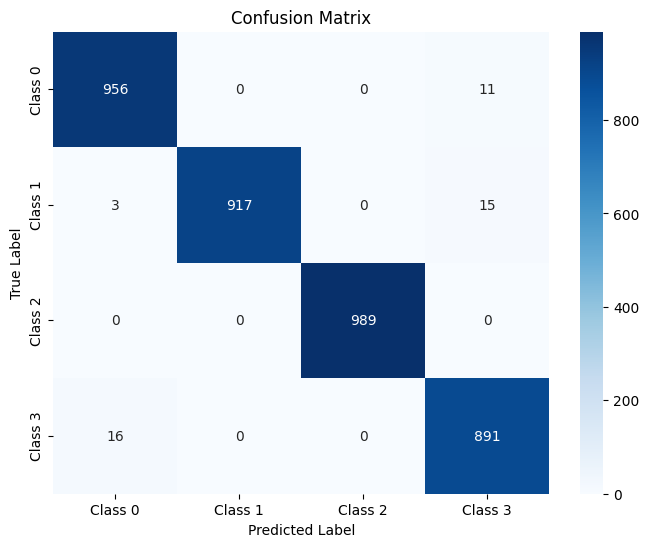

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Class Names (Edit this to match your dataset's class names)
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Classification Report
print("Classification Report:\n",
      classification_report(y_true, y_pred_classes, target_names=class_names))


Classification Report:
               precision    recall  f1-score   support

     Class 0       0.98      0.99      0.98       967
     Class 1       1.00      0.98      0.99       935
     Class 2       1.00      1.00      1.00       989
     Class 3       0.97      0.98      0.98       907

    accuracy                           0.99      3798
   macro avg       0.99      0.99      0.99      3798
weighted avg       0.99      0.99      0.99      3798

